В качестве датасетов были выбраны следующие:

**Классификация** - *data_class.csv* набор данных содержит данные с датчиков, собранные с различных машин, с целью заблаговременного прогнозирования отказов оборудования. Он включает в себя различные показания датчиков, а также зарегистрированные отказы оборудования.

**Регрессия** - *data.csv* набор данных содержит информацию, необходимую для прогнозирования цен на жилье в Москве и Московской области.Он включает в себя различные характеристики, важные для прогнозирования стоимости жилья, такие как местоположение, площадь, наличие удобств и другие факторы, влияющие на цены на недвижимость.

**Практическая задача:**

    Для классификации:
    
        1. заблаговременно узнать о риске сбоя устройств и предотвратить его.
    Для регрессии:
    
        1. рассчет примерной цены квартиры перед продажей, для понимания состояния рынка.

**Выбор метрик качества:**

    Для классификации выбраны:
    
        *Accuracy* — для общей оценки доли правильно предсказанных объектов;
        *F1-score (macro)* — для сбалансированной оценки качества по всем трём классам, особенно важной при возможном дисбалансе.
    
    Для регрессии выбраны:
        *MAE (Mean Absolute Error)* — интерпретируемая метрика средней абсолютной ошибки в рублях;
        *R² (коэффициент детерминации)* — показатель объяснённой дисперсии, позволяющий оценить общее качество модели.

Лабораторная работа №1 
=

**Проведение исследований с алгоритмом KNN**

Классификация
=

**Импорт необхлодимых библиотек**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

**Загрузка Датасета**

In [4]:
df = pd.read_csv('data_class.csv')
df.info()
columns = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
df.columns = columns
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB
   footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail
0         0         7   7    1   6    6  36   3            1     1
1       190         1   3    3   5    1  20   4            1     0
2        31         7   2    2   6    1  24   6            1     0
3        83         4   3    4   5    1  28   6            1     0
4       640         7   5    6   4    0 

**Исследование распределения целевой переменной**

fail
0    551
1    393
Name: count, dtype: int64


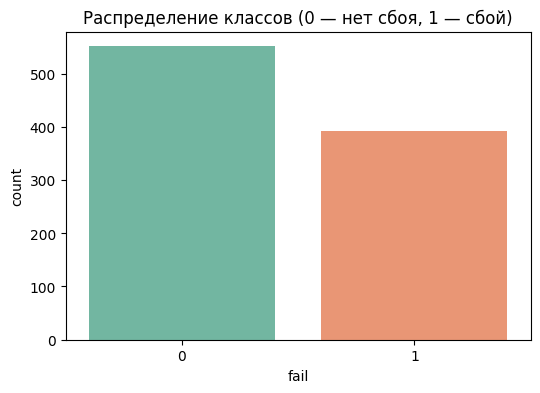

In [5]:
print(df['fail'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fail', palette='Set2')
plt.title('Распределение классов (0 — нет сбоя, 1 — сбой)')
plt.show()

**Разделение данных на train и test**

In [6]:
X = df.drop('fail', axis=1)
y = df['fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


**Создание бейзлайна KNN**

In [8]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train)
y_pred_bl = knn_baseline.predict(X_test)

acc_bl = accuracy_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl, average='macro')

print("Бейзлайн (KNN, k=5, без масштабирования):")
print(f"Accuracy: {acc_bl:.4f} | F1 (macro): {f1_bl:.4f}")

Бейзлайн (KNN, k=5, без масштабирования):
Accuracy: 0.7354 | F1 (macro): 0.7237


**Масштабирование данных через StandartScale**

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)

f1_scaled = f1_score(y_test, y_pred_scaled, average='macro')
print(f"F1 = {f1_scaled:.4f}")

F1 = 0.8975


**Подбор количества соседей**

In [12]:
param_grid = {'n_neighbors': range(1, 51)}
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
f1_best_k = f1_score(y_test, grid_search.predict(X_test_scaled), average='macro')
print(f"лучшее k={best_k}: F1 = {f1_best_k:.4f}")

лучшее k=26: F1 = 0.9025


**Исследование RobustScaler**

In [15]:
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

knn_robust = KNeighborsClassifier(n_neighbors=best_k)
knn_robust.fit(X_train_robust, y_train)
f1_robust = f1_score(y_test, knn_robust.predict(X_test_robust), average='macro')
print(f"Гипотеза 3 (RobustScaler): F1 = {f1_robust:.4f}")

Гипотеза 3 (RobustScaler): F1 = 0.8961


**Использование лучших параметров для нового бейзлайна**


In [17]:
final_scaler = StandardScaler()
X_train_final = final_scaler.fit_transform(X_train)
X_test_final = final_scaler.transform(X_test)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_final, y_train)
y_pred_final = final_model.predict(X_test_final)

acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='macro')

print("Улучшенная модель:")
print(f"Accuracy: {acc_final:.4f} | F1 (macro): {f1_final:.4f}")

Улучшенная модель:
Accuracy: 0.9048 | F1 (macro): 0.9025


**Собственная реализация метода KNN**

In [18]:
class MyKNNClassifier:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_nearest_indices = np.argsort(distances)[:self.n_neighbors]
            k_nearest_labels = self.y_train[k_nearest_indices]
            most_common = Counter(k_nearest_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)

**Использование собственной реализации на сырых данных**

In [24]:
my_knn = MyKNNClassifier(n_neighbors=best_k)
my_knn.fit(X_train, y_train)
y_pred_custom_base = my_knn.predict(X_test)

acc_custom_base = accuracy_score(y_test, y_pred_custom_base)
f1_custom_base = f1_score(y_test, y_pred_custom_base, average='macro')

print("Собственная реализация KNN:")
print(f"Accuracy: {acc_custom_base:.4f} | F1 (macro): {f1_custom_base:.4f}")

Собственная реализация KNN:
Accuracy: 0.7566 | F1 (macro): 0.7391


**Использование собственной реализации на улучшенных данных**

In [25]:
my_knn = MyKNNClassifier(n_neighbors=best_k)
my_knn.fit(X_train_final, y_train)
y_pred_custom = my_knn.predict(X_test_final)

acc_custom = accuracy_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom, average='macro')

print("Собственная реализация KNN:")
print(f"Accuracy: {acc_custom:.4f} | F1 (macro): {f1_custom:.4f}")

Собственная реализация KNN:
Accuracy: 0.9048 | F1 (macro): 0.9025


In [26]:
results = pd.DataFrame({
    'Модель': [
        'Бейзлайн (sklearn)',
        'Улучшенная модель (sklearn)',
        'Собственная реализация (сырые данные)',
        'Собственная реализации (чистые данные)'
    ],
    'Accuracy': [acc_bl, acc_final, acc_custom_base, acc_custom],
    'F1 (macro)': [f1_bl, f1_final, f1_custom_base, f1_custom]
})
results

,Модель,Accuracy,F1 (macro)
0,Бейзлайн (sklearn),0.735450,0.723684
1,Улучшенная модель (sklearn),0.904762,0.902466
2,Собственная реализация (сырые данные),0.756614,0.739076
3,Собственная реализации (чистые данные),0.904762,0.902466


Регрессия
=

**Импорт необхлодимых библиотек**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

**Загрузка Датасета и преобразование числовых столбцов**

In [42]:
df = pd.read_csv('data.csv', header=None)
columns = [
    'price', 'building_type', 'district', 'floor', 'city',
    'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony',
    'floor_level', 'renovation'
]
df.columns = columns
numeric_cols = ['price', 'floor', 'rooms', 'total_area', 'living_area',
                'kitchen_area', 'balcony', 'floor_level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['price'])
print(f"Объектов после загрузки: {len(df)}")

Объектов после загрузки: 22676


**Изучение корреляции**

In [43]:
df_corr = df.copy()
categorical_cols = ['building_type', 'district', 'city', 'renovation']
for col in categorical_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))
correlation = df_corr.corr()['price'].abs().sort_values(ascending=False)
print("Абсолютная корреляция признаков с price:")
print(correlation)

Абсолютная корреляция признаков с price:
price            1.000000
total_area       0.794226
living_area      0.709296
kitchen_area     0.582940
rooms            0.490820
building_type    0.287179
renovation       0.256342
city             0.224412
district         0.126735
floor            0.105382
floor_level      0.022134
balcony          0.019080
Name: price, dtype: float64


**Визуализация корреляции**

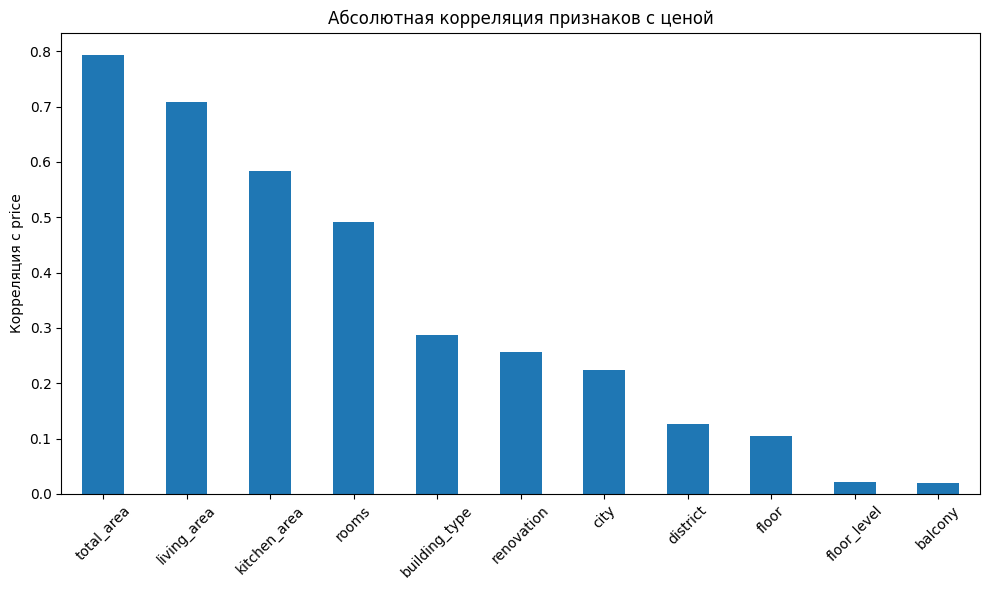

In [44]:
plt.figure(figsize=(10, 6))
correlation.drop('price').plot(kind='bar')
plt.title('Абсолютная корреляция признаков с ценой')
plt.ylabel('Корреляция с price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Начальный бейзлайн**

In [45]:
X_all = df.drop('price', axis=1)
y_all = df['price']

for col in categorical_cols:
    X_all[col] = LabelEncoder().fit_transform(X_all[col].astype(str))

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

knn_baseline = KNeighborsRegressor(n_neighbors=5)
knn_baseline.fit(X_train_all, y_train_all)
y_pred_baseline = knn_baseline.predict(X_test_all)

mae_baseline = mean_absolute_error(y_test_all, y_pred_baseline)
r2_baseline = r2_score(y_test_all, y_pred_baseline)

print("Бейзлайн:")
print(f"MAE: {mae_baseline:,.0f} руб., R²: {r2_baseline:.4f}")

Бейзлайн:
MAE: 13,600,840 руб., R²: 0.6250


**Улучшение точности бейзлайна**

In [59]:
df = df[df['price'] <= 120_000_000]
df = df[(df['total_area'] > 10) & (df['total_area'] <= 200)]
df = df[df['rooms'] > 0]

df['price_per_sqm'] = df['price'] / df['total_area']

high_corr_features = ['total_area', 'rooms', 'floor', 'floor_level', 'price_per_sqm']
X = df[high_corr_features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'n_neighbors': range(1, 100, 2),
    'weights': ['distance']
}
grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

y_pred_improved = grid_search.predict(X_test_scaled)
mae_improved = mean_absolute_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print("Улучшенная модель:")
print(f"Признаки: {high_corr_features}")
print(f"MAE: {mae_improved:,.0f} руб., R²: {r2_improved:.4f}")
print(f"Лучшее k: {grid_search.best_params_['n_neighbors']}")

Улучшенная модель:
Признаки: ['total_area', 'rooms', 'floor', 'floor_level', 'price_per_sqm']
MAE: 745,461 руб., R²: 0.9928
Лучшее k: 5


**Собственная реализация**

In [60]:
class MyKNNRegressor:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_nearest_indices = np.argsort(distances)[:self.n_neighbors]
            k_nearest_values = self.y_train[k_nearest_indices]
            predictions.append(np.mean(k_nearest_values))
        return np.array(predictions)

**Применение собственной реализации для сырых данных**

In [61]:
my_knn = MyKNNRegressor(n_neighbors=grid_search.best_params_['n_neighbors'])
my_knn.fit(X_train, y_train)
y_pred_custom_base = my_knn.predict(X_test)

mae_custom_base = mean_absolute_error(y_test, y_pred_custom_base)
r2_custom_base = r2_score(y_test, y_pred_custom_base)

print(f"MAE: {mae_custom_base:,.0f} руб., R²: {r2_custom_base:.4f}")

MAE: 6,087,776 руб., R²: 0.7042


**Применение собственной реализации для чистых данных**

In [62]:
my_knn = MyKNNRegressor(n_neighbors=grid_search.best_params_['n_neighbors'])
my_knn.fit(X_train_scaled, y_train)
y_pred_custom = my_knn.predict(X_test_scaled)

mae_custom = mean_absolute_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)

print(f"MAE: {mae_custom:,.0f} руб., R²: {r2_custom:.4f}")

MAE: 932,382 руб., R²: 0.9906


**Сравнение итогов**

In [63]:
results = pd.DataFrame({
    'Модель': [
        'Бейзлайн (все признаки)',
        'Улучшенная модель',
        'Собственная реализация сырая',
        'Собственная реализация чистая'
    ],
    'MAE (руб.)': [mae_baseline, mae_improved, mae_custom_base, mae_custom],
    'R²': [r2_baseline, r2_improved, r2_custom_base, r2_custom]
})
results

,Модель,MAE (руб.),R²
0,Бейзлайн (все признаки),1.360084e+07,0.624983
1,Улучшенная модель,7.454608e+05,0.992798
2,Собственная реализация сырая,6.087776e+06,0.704175
3,Собственная реализация чистая,9.323815e+05,0.990619
